In [1]:
from google.colab import files
uploaded = files.upload()

Saving diabetes -3.csv to diabetes -3.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [8]:
df = pd.read_csv("diabetes -3.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Sample Mean Glucose: 130.36
Population Mean Glucose: 120.89453125
Sample Max Glucose: 197
Population Max Glucose: 199


<Figure size 800x500 with 0 Axes>

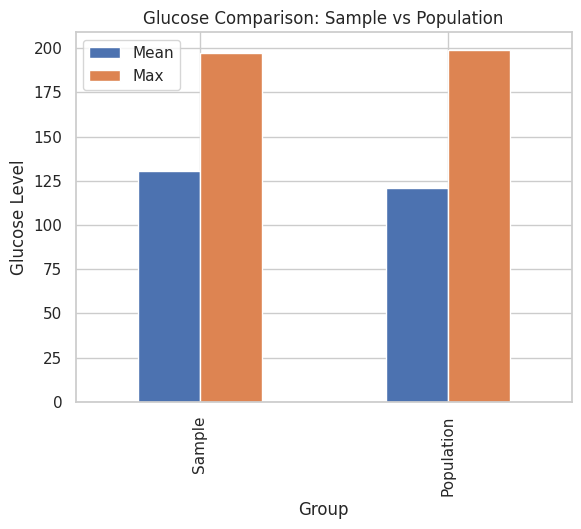

In [9]:
#a)
np.random.seed(123)
sample_25 = df.sample(n=25)
sample_mean_glucose = sample_25["Glucose"].mean()
sample_max_glucose = sample_25["Glucose"].max()
population_mean_glucose = df["Glucose"].mean()
population_max_glucose = df["Glucose"].max()
print("Sample Mean Glucose:", sample_mean_glucose)
print("Population Mean Glucose:", population_mean_glucose)
print("Sample Max Glucose:", sample_max_glucose)
print("Population Max Glucose:", population_max_glucose)
plt.figure(figsize=(8,5))
glucose_stats = pd.DataFrame({
    'Group': ['Sample', 'Population'],
    'Mean': [sample_mean_glucose, population_mean_glucose],
    'Max': [sample_max_glucose, population_max_glucose]
})
glucose_stats.set_index('Group')[['Mean', 'Max']].plot(kind='bar')
plt.title("Glucose Comparison: Sample vs Population")
plt.ylabel("Glucose Level")
plt.show()

Sample 98th Percentile BMI: 45.263999999999996
Population 98th Percentile BMI: 47.52599999999996


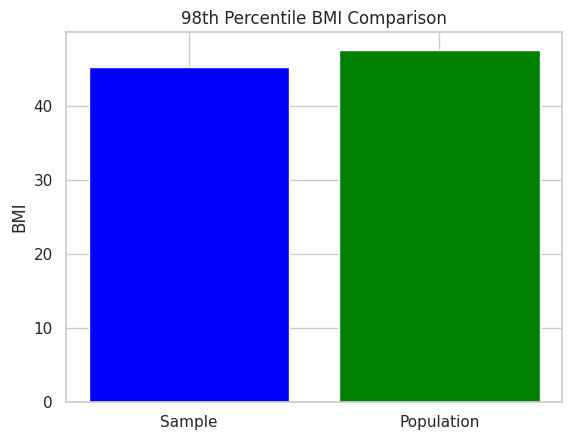

In [10]:
#b)
sample_bmi_98 = np.percentile(sample_25["BMI"], 98)
population_bmi_98 = np.percentile(df["BMI"], 98)
print("Sample 98th Percentile BMI:", sample_bmi_98)
print("Population 98th Percentile BMI:", population_bmi_98)
plt.bar(["Sample", "Population"], [sample_bmi_98, population_bmi_98], color=["blue", "green"])
plt.title("98th Percentile BMI Comparison")
plt.ylabel("BMI")
plt.show()

Bootstrap Avg Mean: 69.15464
Population Mean: 69.10546875
Bootstrap Avg Std Dev: 19.204871569984963
Population Std Dev: 19.355807170644777
Bootstrap Avg 98th Percentile: 98.02348000000003
Population 98th Percentile: 99.31999999999994


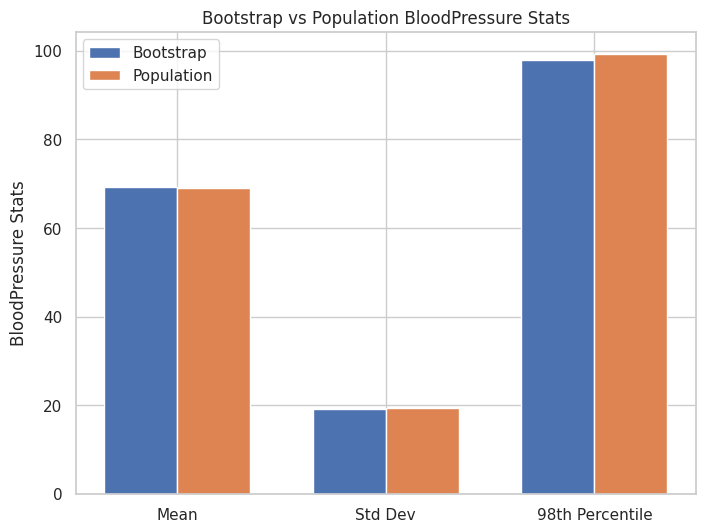

In [11]:
#c)
def get_bootstrap_stats(data, variable, n_samples=500, sample_size=150):
    means = []
    stds = []
    percentiles = []
    for _ in range(n_samples):
        sample = data[variable].sample(n=sample_size, replace=True)
        means.append(sample.mean())
        stds.append(sample.std())
        percentiles.append(np.percentile(sample, 98))
    return {
        "mean_avg": np.mean(means),
        "std_avg": np.mean(stds),
        "percentile_avg": np.mean(percentiles),
        "means": means,
        "stds": stds,
        "percentiles": percentiles
    }
bp_stats = get_bootstrap_stats(df, "BloodPressure")
bp_mean_pop = df["BloodPressure"].mean()
bp_std_pop = df["BloodPressure"].std()
bp_98_pop = np.percentile(df["BloodPressure"], 98)
print("Bootstrap Avg Mean:", bp_stats["mean_avg"])
print("Population Mean:", bp_mean_pop)
print("Bootstrap Avg Std Dev:", bp_stats["std_avg"])
print("Population Std Dev:", bp_std_pop)
print("Bootstrap Avg 98th Percentile:", bp_stats["percentile_avg"])
print("Population 98th Percentile:", bp_98_pop)
labels = ['Mean', 'Std Dev', '98th Percentile']
bootstrap_vals = [bp_stats["mean_avg"], bp_stats["std_avg"], bp_stats["percentile_avg"]]
population_vals = [bp_mean_pop, bp_std_pop, bp_98_pop]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width/2, bootstrap_vals, width, label='Bootstrap')
rects2 = ax.bar(x + width/2, population_vals, width, label='Population')
ax.set_ylabel('BloodPressure Stats')
ax.set_title('Bootstrap vs Population BloodPressure Stats')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()